In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/AgriVision-AI/datasets/PlantVillage"

print(os.path.exists(dataset_path))

True


In [ ]:
import os

classes = os.listdir(dataset_path)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 10
['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [ ]:
print(os.listdir(dataset_path))

['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
classes = [folder for folder in os.listdir(dataset_path) if folder.startswith("Tomato")]

print("Number of Tomato Classes:", len(classes))
print(classes)

Number of Tomato Classes: 10
['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [ ]:
healthy_folder = os.path.join(dataset_path, "Tomato_healthy")

In [ ]:
image_name = os.listdir(healthy_folder)[0]

image_path = os.path.join(healthy_folder, image_name)

print(image_path)

/content/drive/MyDrive/AgriVision-AI/datasets/PlantVillage/Tomato_healthy/56f87203-cfd4-4e2c-b2d7-df17983d8267___GH_HL Leaf 374.JPG


In [ ]:
image = cv2.imread(image_path)

In [ ]:
print(type(image))

<class 'numpy.ndarray'>


In [ ]:
print(image.shape)

(256, 256, 3)


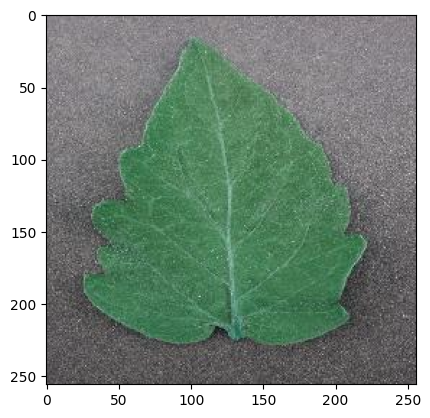

In [ ]:
plt.imshow(image)
plt.show()

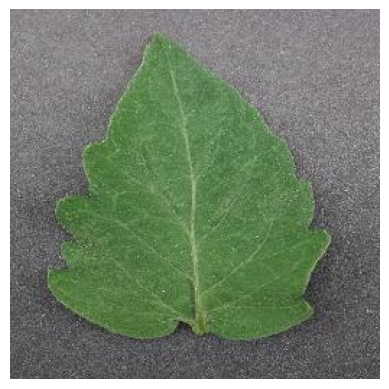

In [ ]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [ ]:
print(image_rgb[0, 0])

[128 123 127]


In [ ]:
print("Height :", image_rgb.shape[0])
print("Width  :", image_rgb.shape[1])
print("Channels:", image_rgb.shape[2])

print("Data Type:", image_rgb.dtype)

print("Minimum Pixel:", image_rgb.min())

print("Maximum Pixel:", image_rgb.max())

Height : 256
Width  : 256
Channels: 3
Data Type: uint8
Minimum Pixel: 0
Maximum Pixel: 241


In [ ]:
print(image_rgb[100, 50])

[142 154 134]


Original Shape : (256, 256, 3)
Resized Shape  : (128, 128, 3)


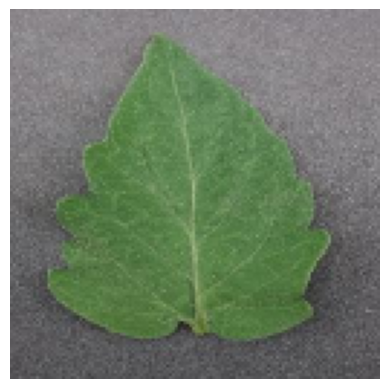

In [ ]:
IMG_SIZE = 128

resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))

print("Original Shape :", image_rgb.shape)
print("Resized Shape  :", resized.shape)

plt.imshow(resized)
plt.axis("off")
plt.show()

In [ ]:
normalized = resized / 255.0

print("Minimum:", normalized.min())
print("Maximum:", normalized.max())

Minimum: 0.06666666666666667
Maximum: 0.7411764705882353


In [ ]:
print(resized.dtype)

print(normalized.dtype)

uint8
float64


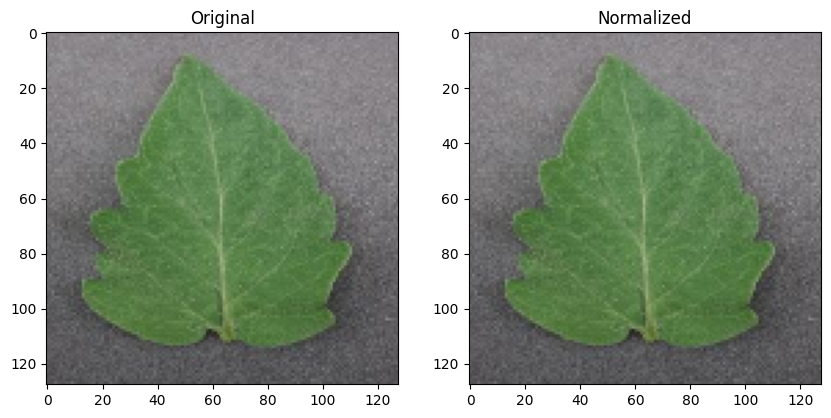

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(resized)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(normalized)
plt.title("Normalized")

plt.show()

In [ ]:
print(resized[50,50])

[ 94 134  82]


In [ ]:
print(normalized[50,50])

[0.36862745 0.5254902  0.32156863]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'

)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [ ]:
model = Sequential()

In [ ]:
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(128,128,3)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [ ]:
import os

tomato_classes = [folder for folder in os.listdir(dataset_path)
                  if folder.startswith("Tomato")]

print("Number of classes:", len(tomato_classes))

for c in tomato_classes:
    print(c)

Number of classes: 10
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Target_Spot
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato__Tomato_mosaic_virus
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot


In [ ]:
import tensorflow as tf

IMG_SIZE = (128,128)
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 16028 files belonging to 10 classes.


In [ ]:
class_names = dataset.class_names

print(class_names)

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


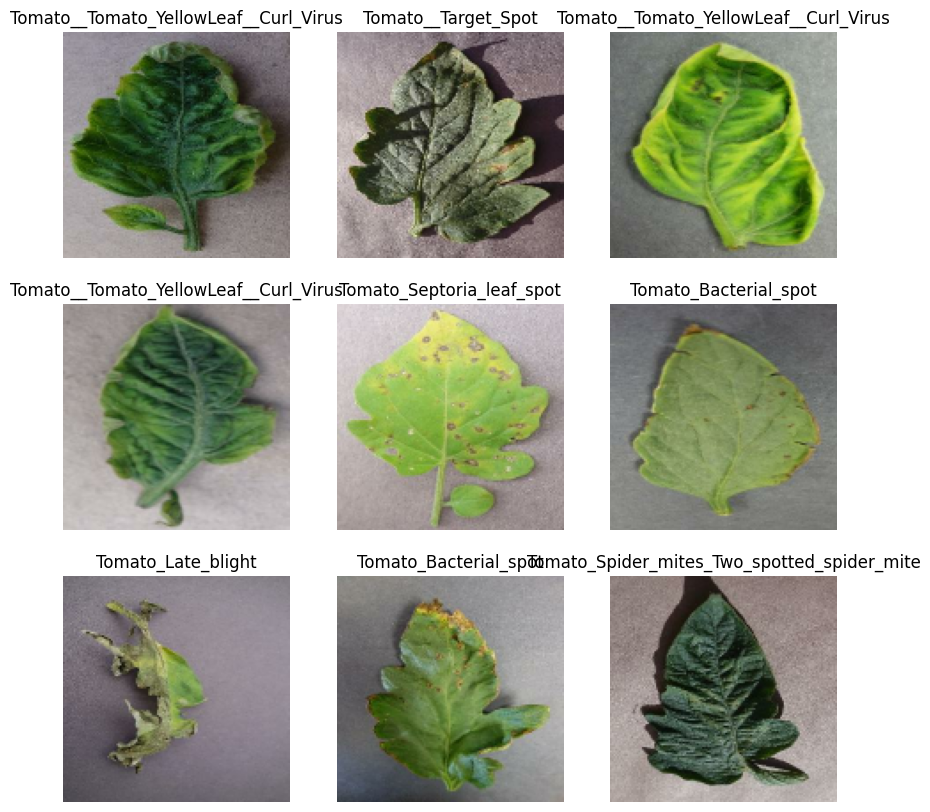

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [ ]:
dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

train_ds = dataset.take(train_size)

remaining = dataset.skip(train_size)

val_ds = remaining.take(val_size)

test_ds = remaining.skip(val_size)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

num_classes = len(class_names)

model = Sequential([

    Rescaling(1./255),

    Conv2D(32,(3,3),activation='relu',padding='same'),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(num_classes,activation='softmax')
])

In [ ]:
model.build(input_shape=(None,128,128,3))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,970 (16.36 MB)

 Trainable params: 4,288,970 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 16028 files belonging to 10 classes.
Using 12823 files for training.
Found 16028 files belonging to 10 classes.
Using 3205 files for validation.


In [ ]:
print(train_ds.class_names)

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
metrics=['accuracy']

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 2468s 6s/step - accuracy: 0.5464 - loss: 1.3156 - val_accuracy: 0.7376 - val_loss: 0.7360
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.7445 - loss: 0.7493 - val_accuracy: 0.8387 - val_loss: 0.4521
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.7990 - loss: 0.5838 - val_accuracy: 0.8702 - val_loss: 0.3610
Epoch 4/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.8273 - loss: 0.4861 - val_accuracy: 0.8655 - val_loss: 0.4068
Epoch 5/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 50s 125ms/step - accuracy: 0.8569 - loss: 0.4111 - val_accuracy: 0.9098 - val_loss: 0.2729
Epoch 6/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 131ms/step - accuracy: 0.8710 - loss: 0.3684 - val_accuracy: 0.9036 - val_loss: 0.2920
Epoch 7/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 127ms/step - accuracy: 0.8905 - loss: 0.3242 - val_accuracy: 0.9111 - val_loss: 0.2589
Epoch 8/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 128ms/step - accuracy: 0.8996 - loss: 0.

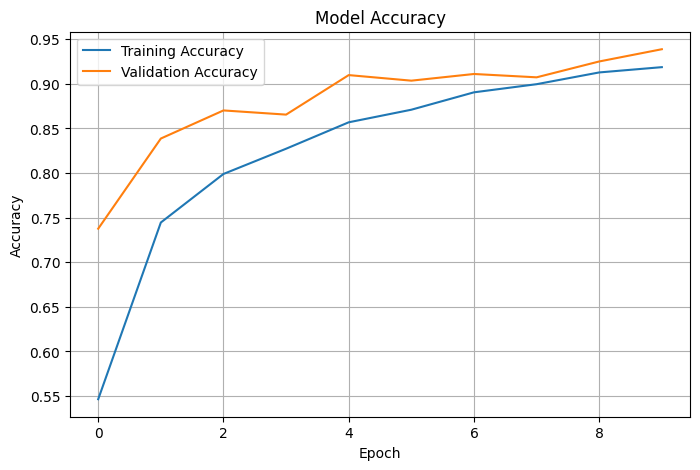

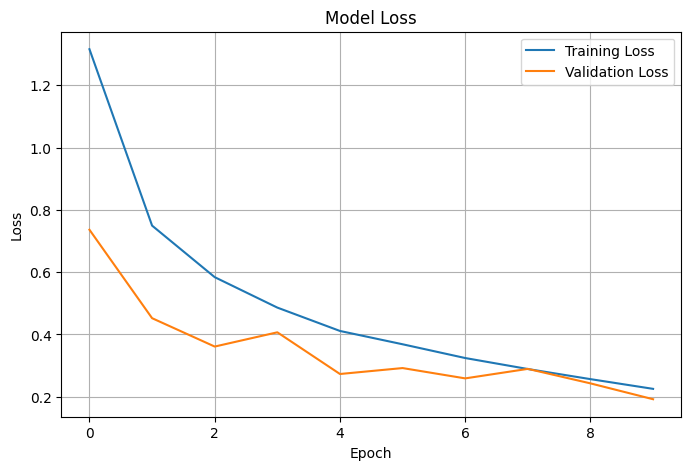

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/AgriVision-AI/models", exist_ok=True)

In [ ]:
model.save("/content/drive/MyDrive/AgriVision-AI/models/agri_vision_ai.keras")

In [ ]:
import pickle

with open("/content/drive/MyDrive/AgriVision-AI/models/history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
import json

with open("/content/drive/MyDrive/AgriVision-AI/models/class_names.json", "w") as f:
    json.dump(train_ds.class_names, f)

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.9388 - loss: 0.1920
Validation Loss     : 0.1920
Validation Accuracy : 0.9388


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.class_names
))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.95      0.99      0.97       426
                        Tomato_Early_blight       0.85      0.78      0.81       182
                         Tomato_Late_blight       0.91      0.92      0.92       372
                           Tomato_Leaf_Mold       0.95      0.86      0.91       191
                  Tomato_Septoria_leaf_spot       0.89      0.94      0.92       369
Tomato_Spider_mites_Two_spotted_spider_mite       0.99      0.87      0.93       327
                        Tomato__Target_Spot       0.88      0.94      0.91       284
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      0.99      0.99       676
                Tomato__Tomato_mosaic_virus       0.84      0.96      0.90        67
                             Tomato_healthy       0.99      0.99      0.99       311

                                   accuracy                    

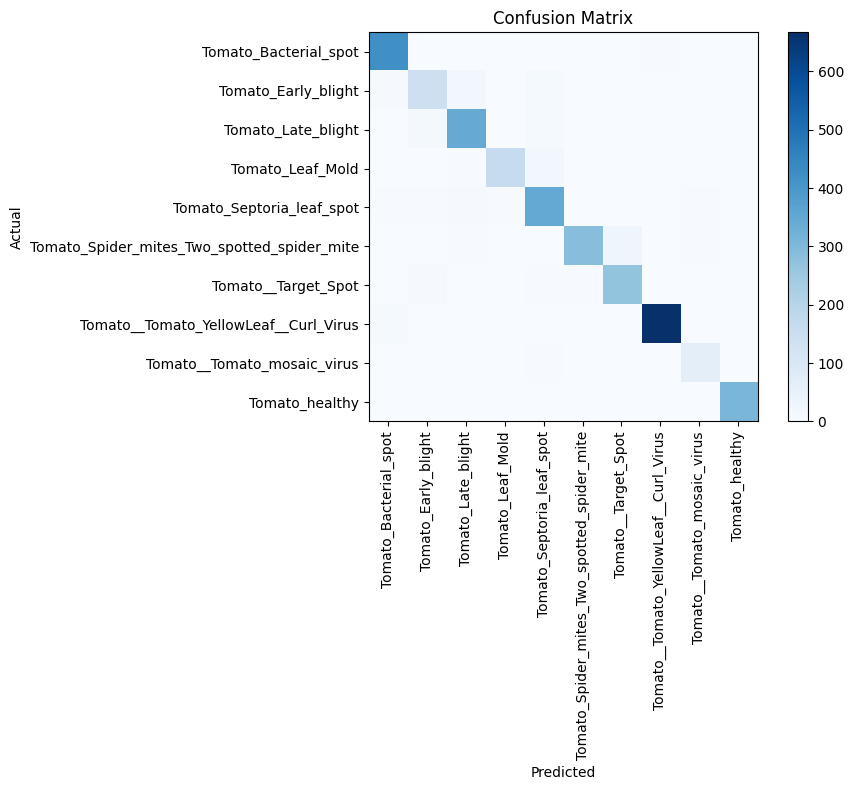

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(train_ds.class_names))
plt.xticks(tick_marks, train_ds.class_names, rotation=90)
plt.yticks(tick_marks, train_ds.class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.show()

In [ ]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tom_test1.jpg to tom_test1.jpg


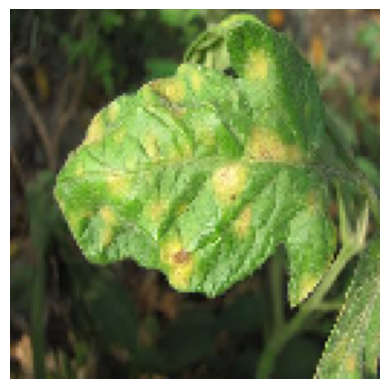

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

image_path = "/content/tom_test1.jpg"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 128, 128, 3)


In [ ]:
predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)

confidence = np.max(predictions)

print("Predicted Class:", train_ds.class_names[predicted_class])
print("Confidence:", confidence*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
Predicted Class: Tomato_Late_blight
Confidence: 99.92461


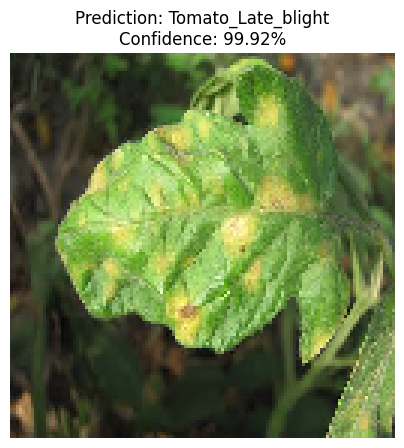

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediction: {train_ds.class_names[predicted_class]}\n"
    f"Confidence: {confidence*100:.2f}%"
)

plt.show()

In [ ]:
predictions = model.predict(img_array)[0]

top3 = np.argsort(predictions)[-3:][::-1]

print("Top 3 Predictions\n")

for i in top3:
    print(f"{train_ds.class_names[i]:45s} {predictions[i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Top 3 Predictions

Tomato_Late_blight                            99.92%
Tomato_Early_blight                           0.08%
Tomato__Tomato_YellowLeaf__Curl_Virus         0.00%


In [ ]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting un